In [16]:
### Exploratory data analysis, geothermal reservoir temperature prediction using machine learning techniques.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
### Change commas for dots in original csv file

import csv

input_file = 'geochemical_data.csv'
output_file = 'geochemical_data_mod.csv'

with open(input_file, 'r', newline='', encoding='utf-8') as infile, open(output_file, 'w', newline='', encoding='utf-8') as outfile:
    reader = csv.reader(infile, delimiter=',')
    writer = csv.writer(outfile, delimiter=',')

    for row in reader:
        new_row = [col.replace(',', '.') if col.replace(',','').replace('.','').isdigit() else col for col in row]
        writer.writerow(new_row)

print(f'Processed CSV file as {output_file} to replace commas for dots.')

Processed CSV file as geochemical_data_mod.csv to replace commas for dots.


In [ ]:
### Exploratory Data Analysis ###

df = pd.read_csv('geochemical_data_mod.csv')

# Principal information about the dataset

print('🔹First 5 rows:\n', df.head())
print('\n🔹Last 5 rows:\n', df.tail())
print('\n🔹Dataset Shape:\n', df.shape)
print('\n🔹Column Info: ')
print('\n', df.info())

print('\n🔹Column names:\n', df.columns.tolist())
print('\n🔹Data types:\n', df.dtypes)
print('\n🔹Missing values:\n', df.isnull().sum())
print('\n🔹Duplicates Count:', df.duplicated().sum())

print('\n🔹Summary Statistics:\n', df.describe(include='all').T)


🔹First 5 rows:
                   name manifestation_type geothermal_system       id  t_out  \
0  Rincón de las papas     Thermal spring            Domuyo  RP1(jp)   46.0   
1  Rincón de las papas     Thermal spring            Domuyo  RP2(jp)   40.2   
2  Rincón de las papas     Thermal spring            Domuyo   RP(88)   39.5   
3            El Humazo           Fumarole            Domuyo  EH1(jp)   97.5   
4            El Humazo           Fumarole            Domuyo  EH1(88)   93.5   

    pH  ac_carbonate  chloride  sulfate  calcium  magnesium  sodium  \
0  6.9         740.0     970.0    115.0    102.0       17.2   715.0   
1  7.0         780.0    2900.0     76.0    209.0       50.7  1570.0   
2  6.6        1098.0    2400.0     89.0     78.0       50.0  1495.0   
3  7.2         100.0    2000.0    230.0     34.6        0.2  1330.0   
4  8.2          98.0    1750.0    259.0     33.0        0.4  1185.0   

   potassium  lithium  silica  δ18O-H2O  δD-H2O  T_reservoir  
0       72.0      4


Missing Data:
              Missing Values  Percentage
ac_carbonate               5    2.840909
magnesium                 26   14.772727
lithium                   10    5.681818
silica                     8    4.545455
δ18O-H2O                  45   25.568182
δD-H2O                    39   22.159091


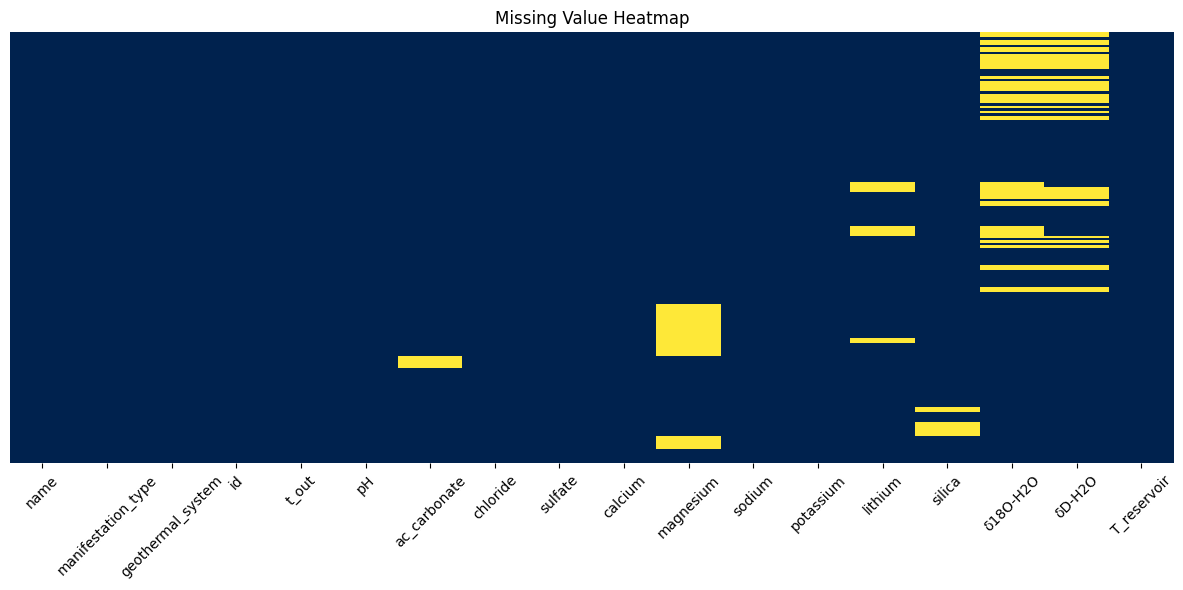

In [ ]:
# Handling missing values

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_data = pd.concat([missing_values, missing_percent], axis=1)
missing_data.columns = ['Missing Values', 'Percentage']
print("\nMissing Data:")
print(missing_data[missing_data['Missing Values'] > 0])

plt.figure(figsize=(12, 6))
plt.title('Missing Value Heatmap')
sns.heatmap(df.isnull(), cbar=False, cmap='cividis', yticklabels=False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()


In [ ]:
# Replace missing values with the median of each column

df_final = df.apply(lambda x: x.fillna(x.median()) if x.dtype != 'O' else x)

# Return to original negative values for δ18O-H2O and δD-H2O columns
df_final['δ18O-H2O'] = -df_final['δ18O-H2O']
df_final['δD-H2O'] = -df_final['δD-H2O']

print('\n🔹Missing values:\n', df_final.isnull().sum())


🔹Missing values:
 name                  0
manifestation_type    0
geothermal_system     0
id                    0
t_out                 0
pH                    0
ac_carbonate          0
chloride              0
sulfate               0
calcium               0
magnesium             0
sodium                0
potassium             0
lithium               0
silica                0
δ18O-H2O              0
δD-H2O                0
T_reservoir           0
dtype: int64


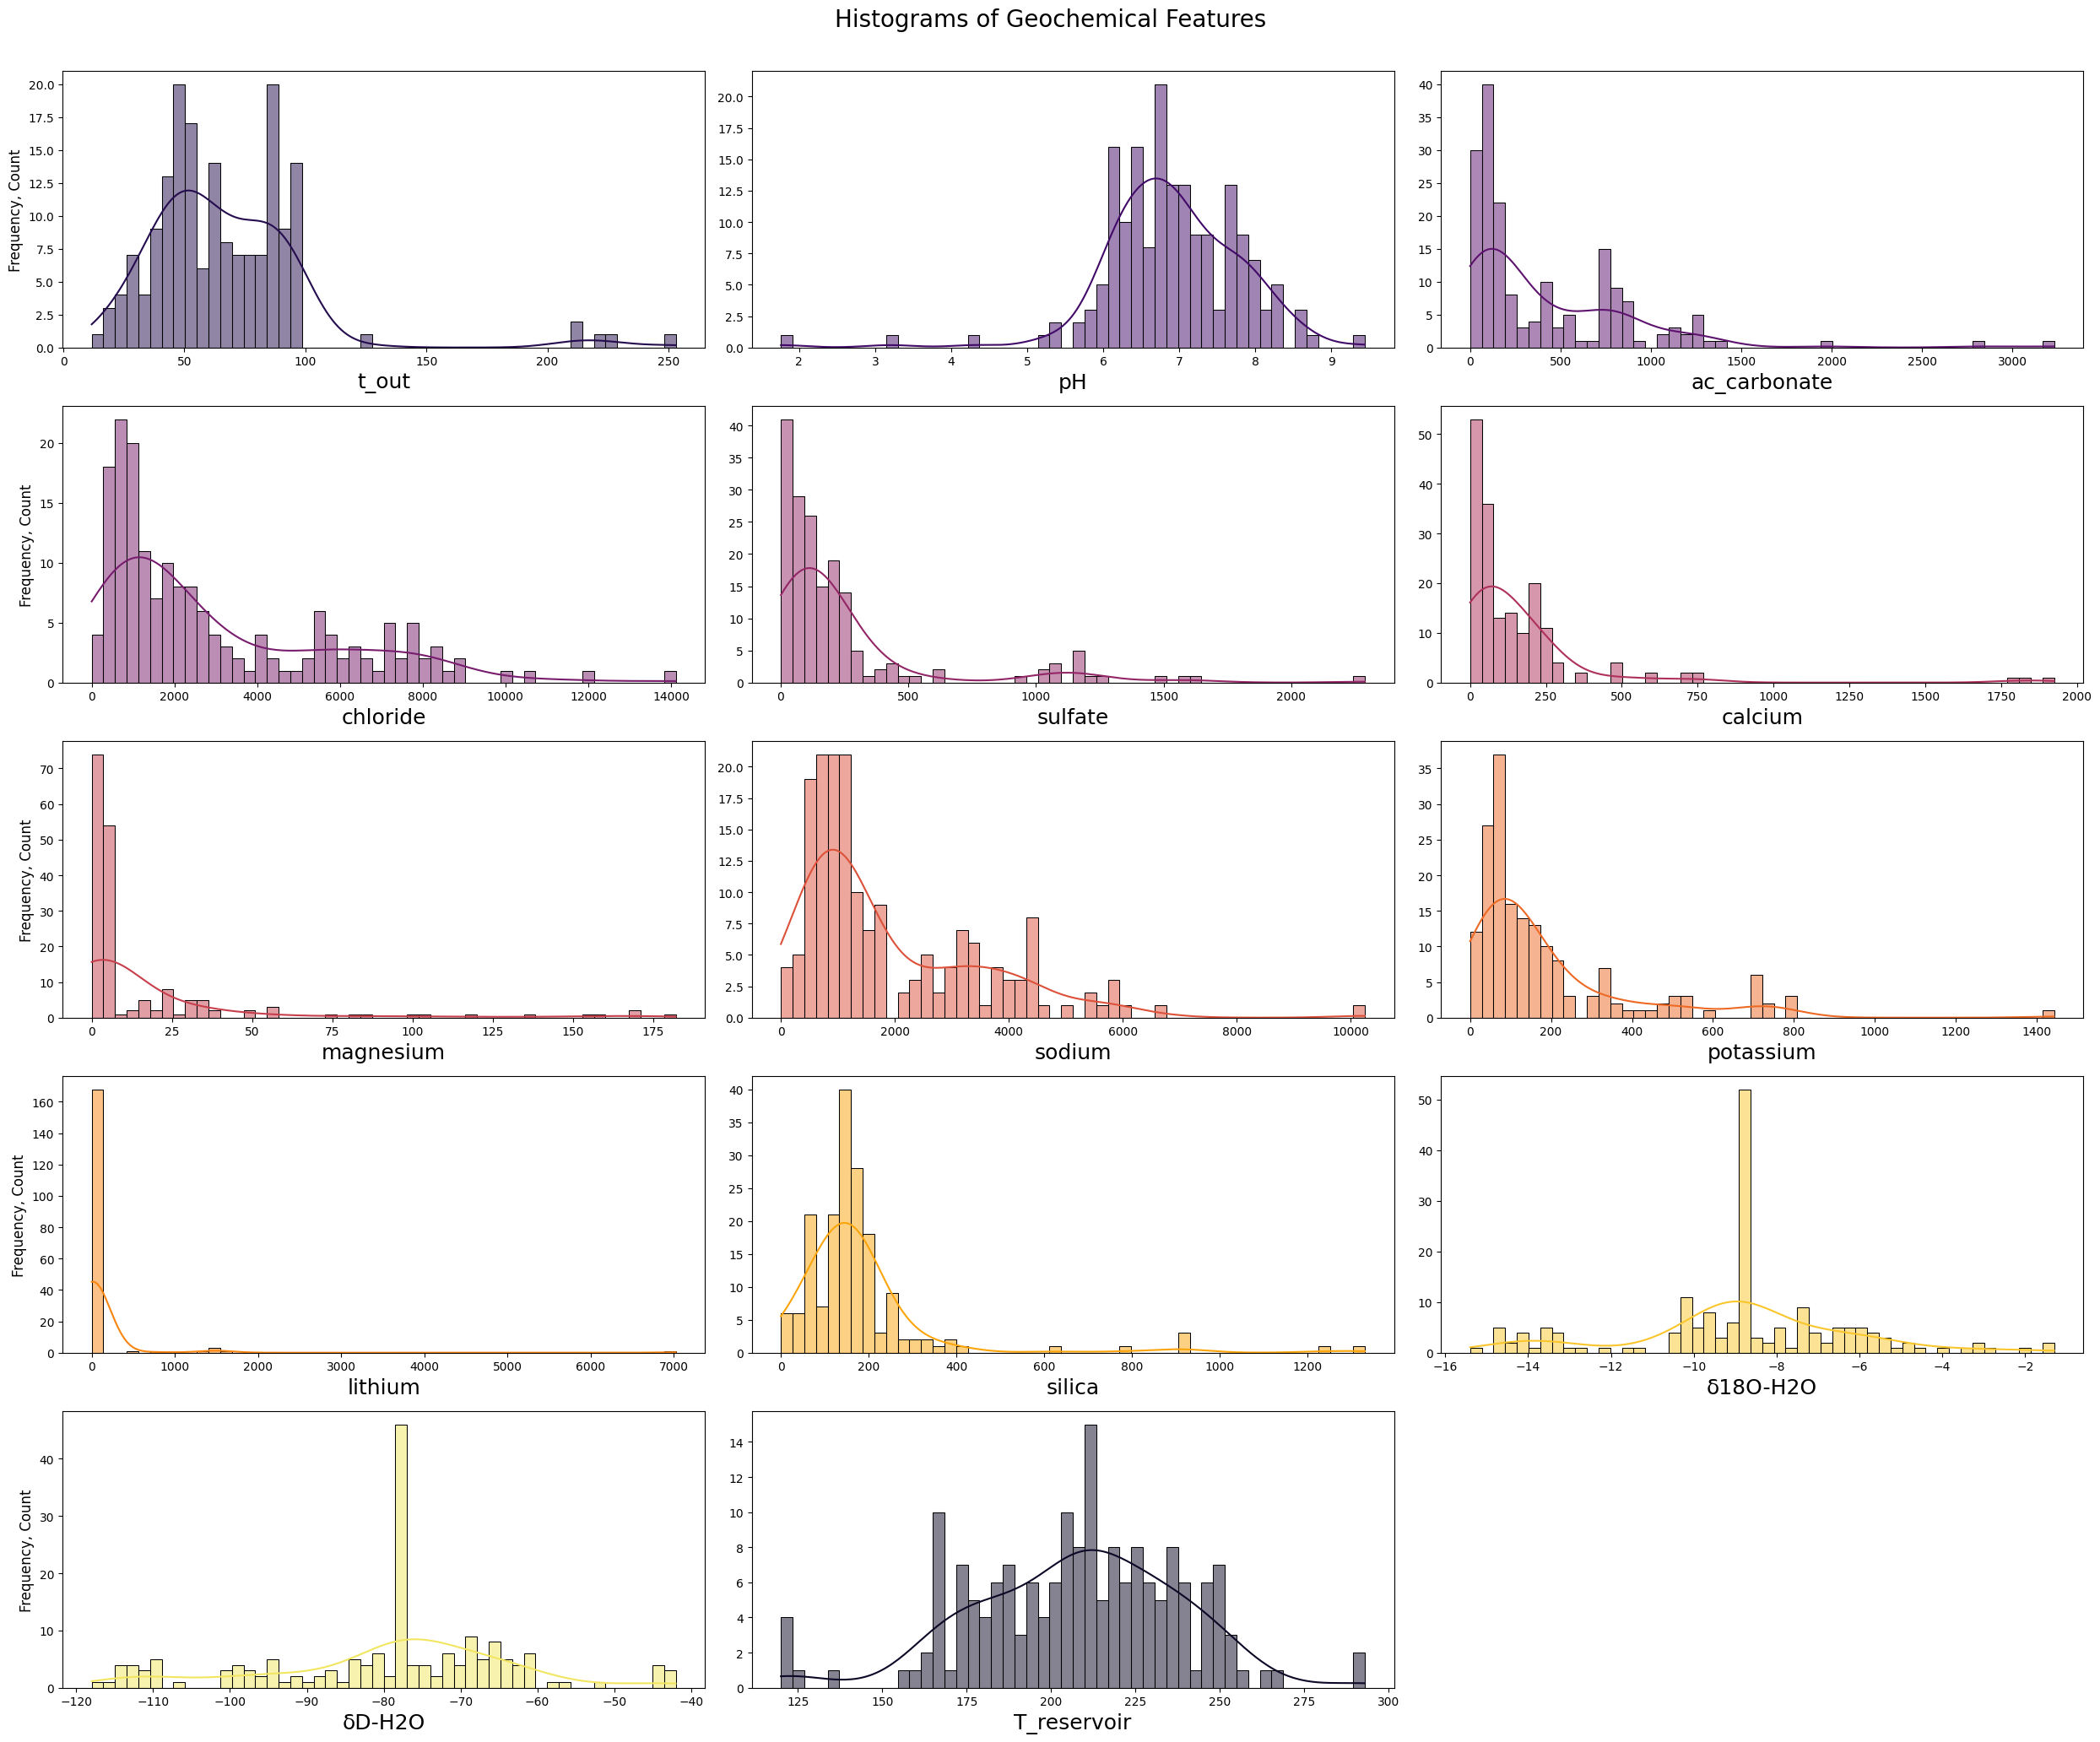

In [ ]:
# Distribution plots of geochemical features

numeric_cols = df_final.select_dtypes(include=["number"]).columns  # Select only numeric columns
if not numeric_cols.empty:
    plt.figure(figsize=(25, 20))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(len(numeric_cols) // 3 + 1, 3, i)
        sns.histplot(df_final[col], bins=50, kde=True, color=sns.color_palette("inferno", len(numeric_cols))[i % len(numeric_cols)])
        #plt.title(f'Distribution of {col}', fontsize=14)
        plt.xlabel(col, fontsize=18)
        if (i - 1) % 3 == 0: 
            plt.ylabel('Frequency, Count', fontsize=12)
        else:
            plt.ylabel('')
    
    plt.tight_layout()
    plt.suptitle("Histograms of Geochemical Features", y=1.03, fontsize=20)
    #plt.savefig('histograms_geochemical_features.png')
    plt.show()
    plt.close()

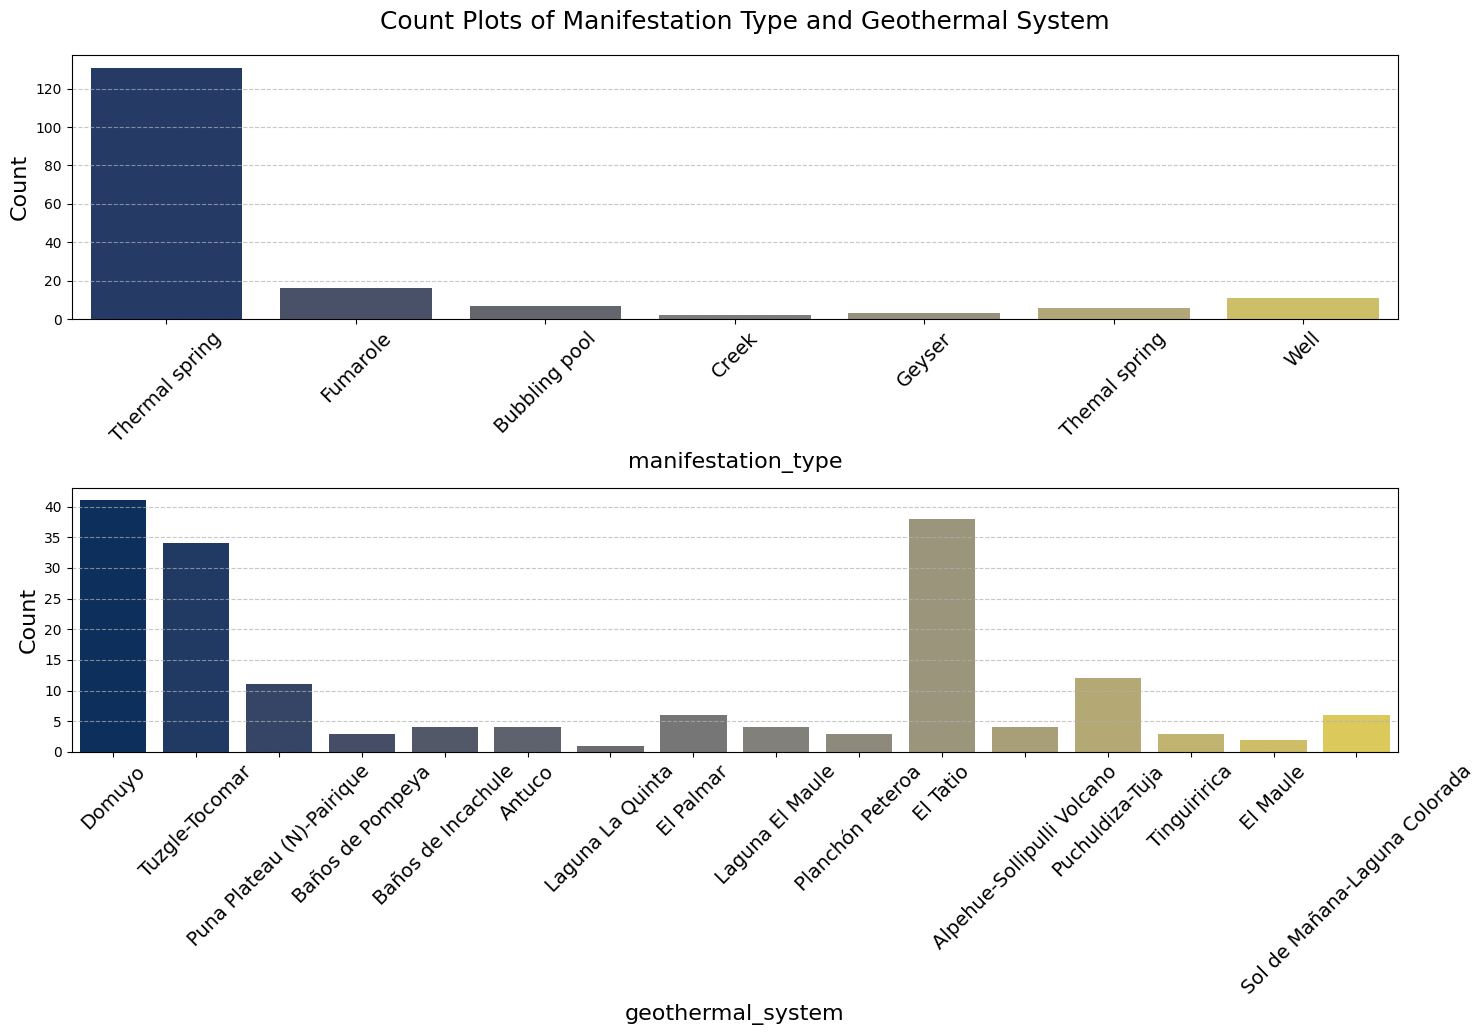

In [31]:
# Count plots for categorical features
categorical_columns = ['manifestation_type', 'geothermal_system']

plt.figure(figsize=(15, 10))
for i, column in enumerate(categorical_columns):
    plt.subplot(2, 1, i+1)
    top_categories = df_final[column].value_counts().nlargest(25).index
    sns.countplot(x=column, data=df_final[df_final[column].isin(top_categories)], palette="cividis", hue=column)
    #plt.title(column, fontsize=18)
    plt.xticks(rotation=45, fontsize=14)
    plt.xlabel(column, fontsize=16)
    plt.ylabel('Count', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.suptitle("Count Plots of Manifestation Type and Geothermal System", y=1.03, fontsize=18)
plt.show()

# plt.savefig('categorical_distributions.png')
plt.close()

/tmp/ipykernel_25069/1144345062.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=np.zeros(len(df_final)), y=df_final[column], palette="viridis", flierprops=flierprops, legend=False)
/tmp/ipykernel_25069/1144345062.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=np.zeros(len(df_final)), y=df_final[column], palette="viridis", flierprops=flierprops, legend=False)
/tmp/ipykernel_25069/1144345062.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=np.zeros(len(df_final)), y=df_final[column], palette="viridis", flierprops=flierprop

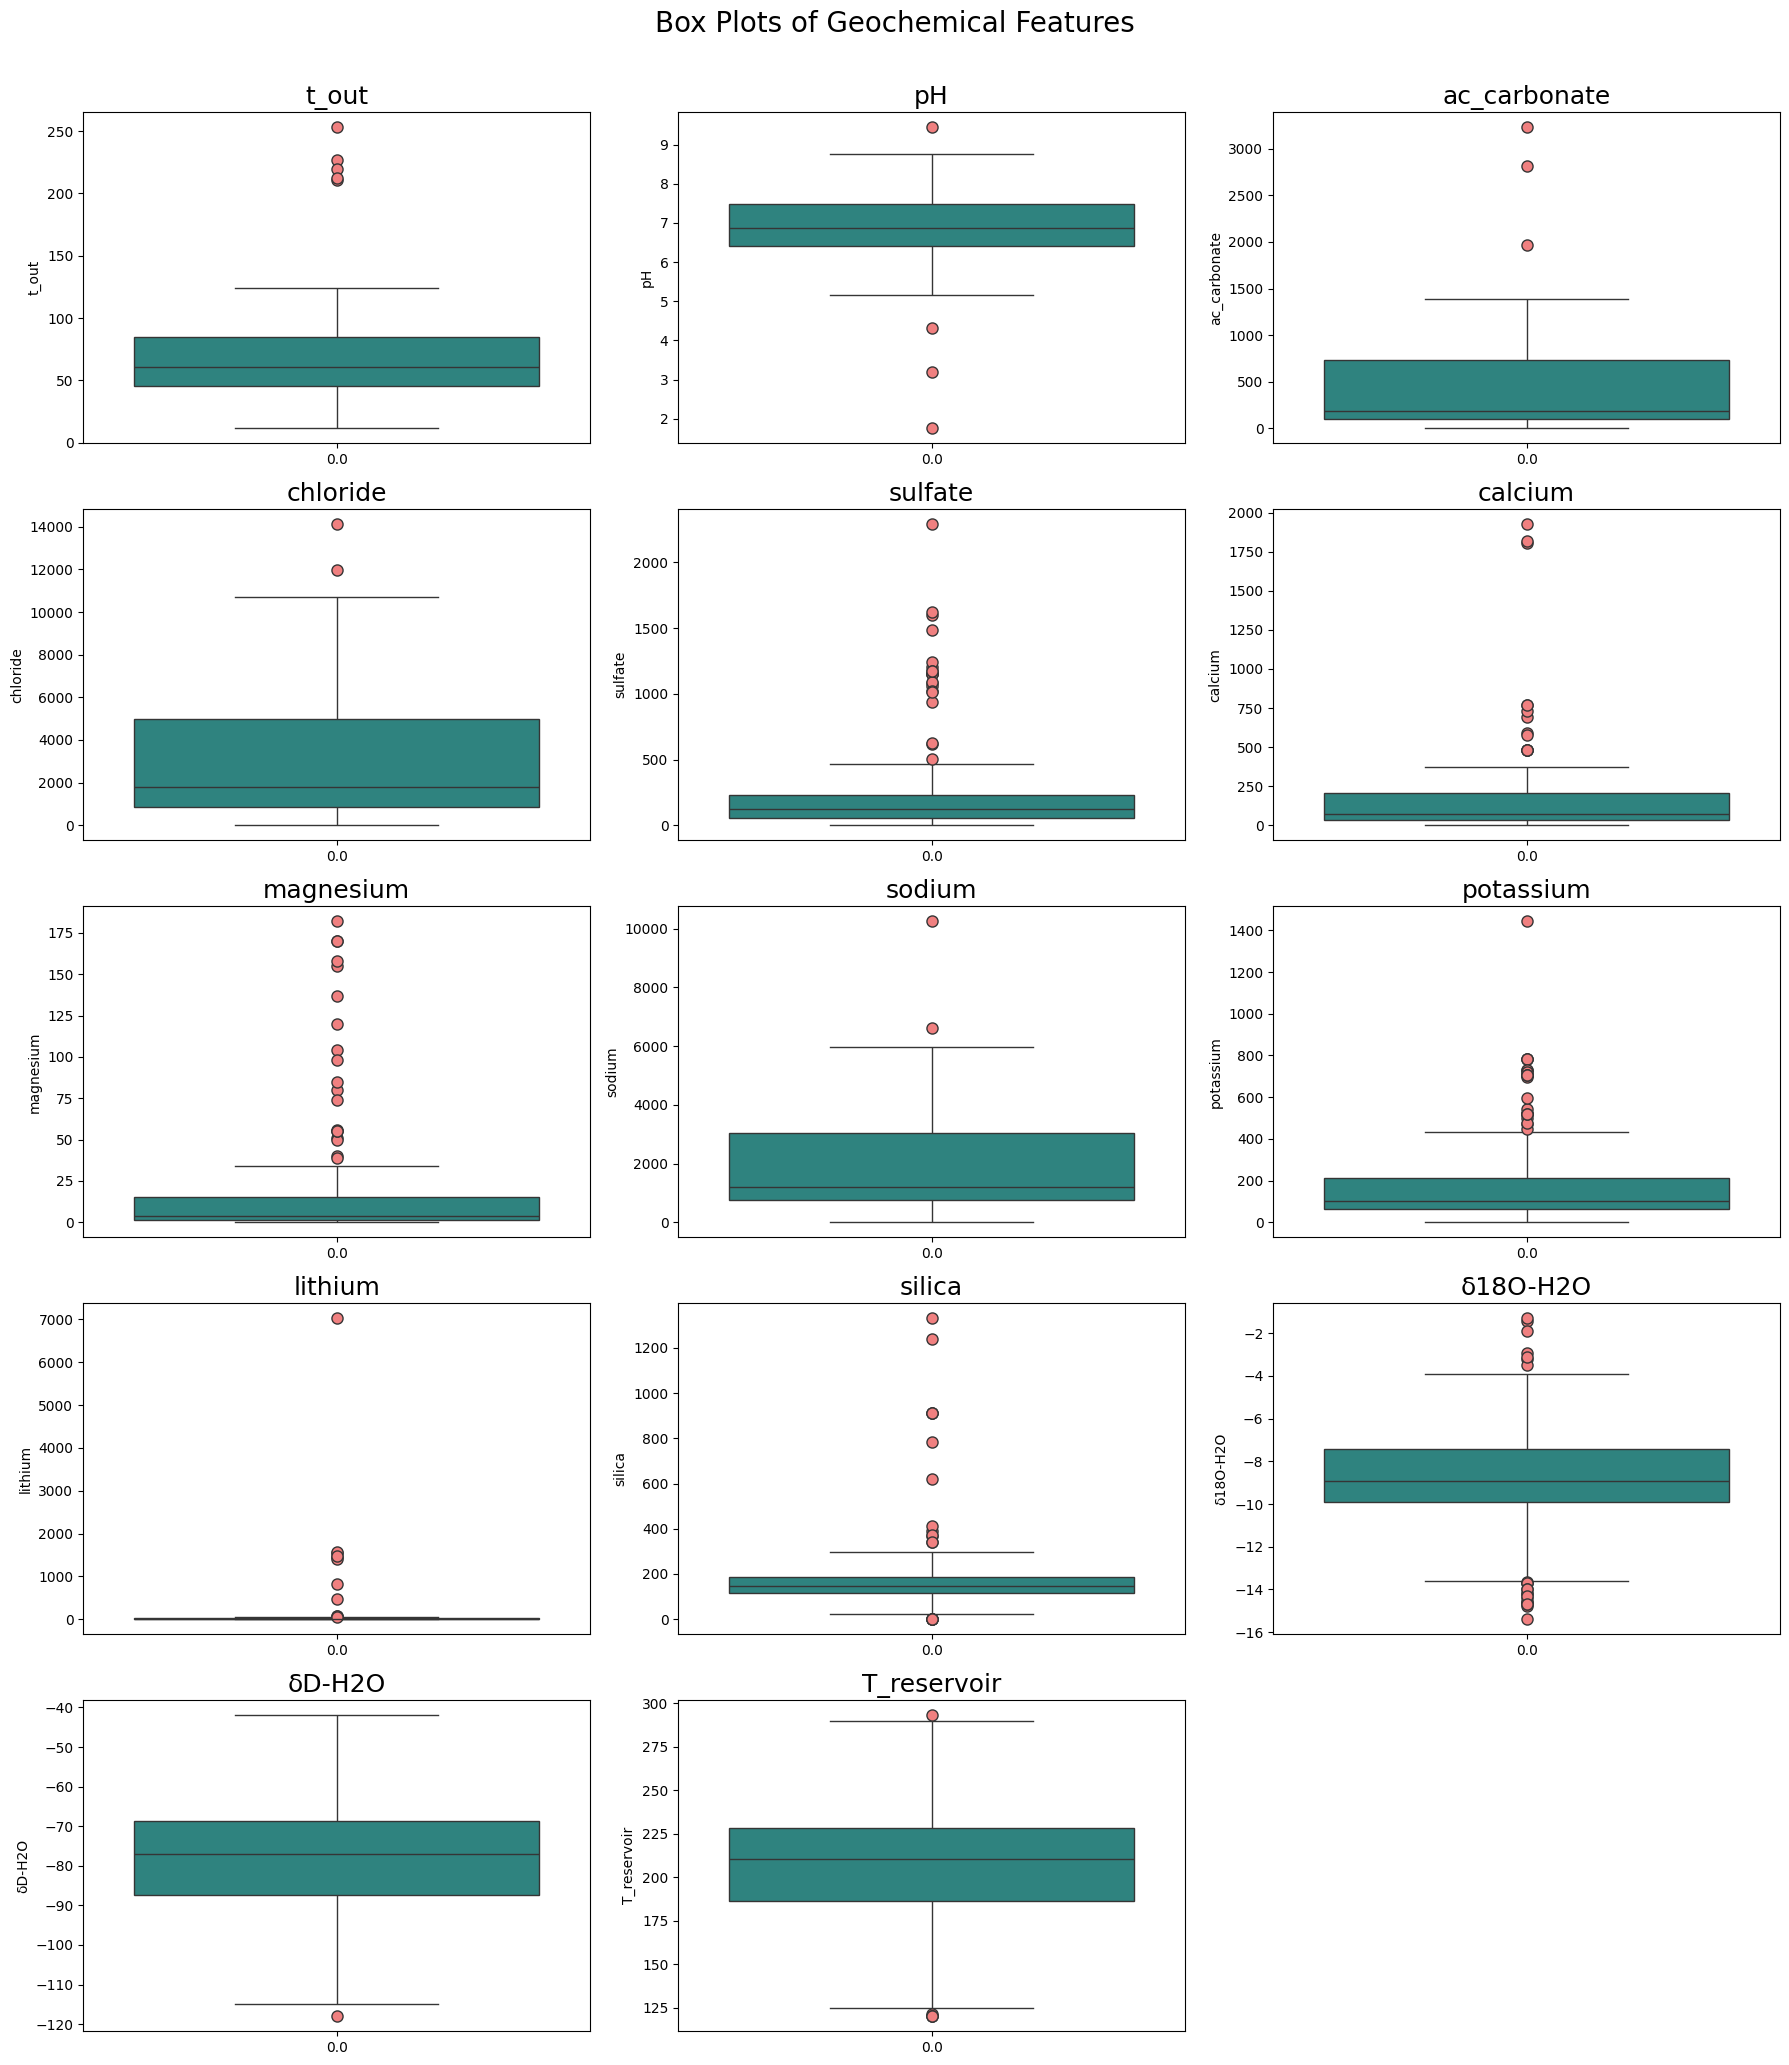

In [ ]:
# Box plots to check outliers
numeric_cols = df_final.select_dtypes(include=["number"]).columns  # Only numeric columns

num_cols = len(numeric_cols)
num_rows = (num_cols // 3) + 1

flierprops = dict(marker='o', markerfacecolor='lightcoral', markersize=8, linestyle='none') # props of outlier points

plt.figure(figsize=(18, num_rows * 4))
for i, column in enumerate(numeric_cols):
    plt.subplot(num_rows, 3, i+1)
    sns.boxplot(y=df_final[column], palette="viridis", flierprops=flierprops)
    plt.title(column, fontsize=18)
    #plt.ylabel(column, fontsize=16)
    plt.xlabel('')
plt.tight_layout()
plt.suptitle("Box Plots of Geochemical Features", y=1.03, fontsize=20)
plt.show()

# plt.savefig('outliers_boxplot.png')
plt.close()

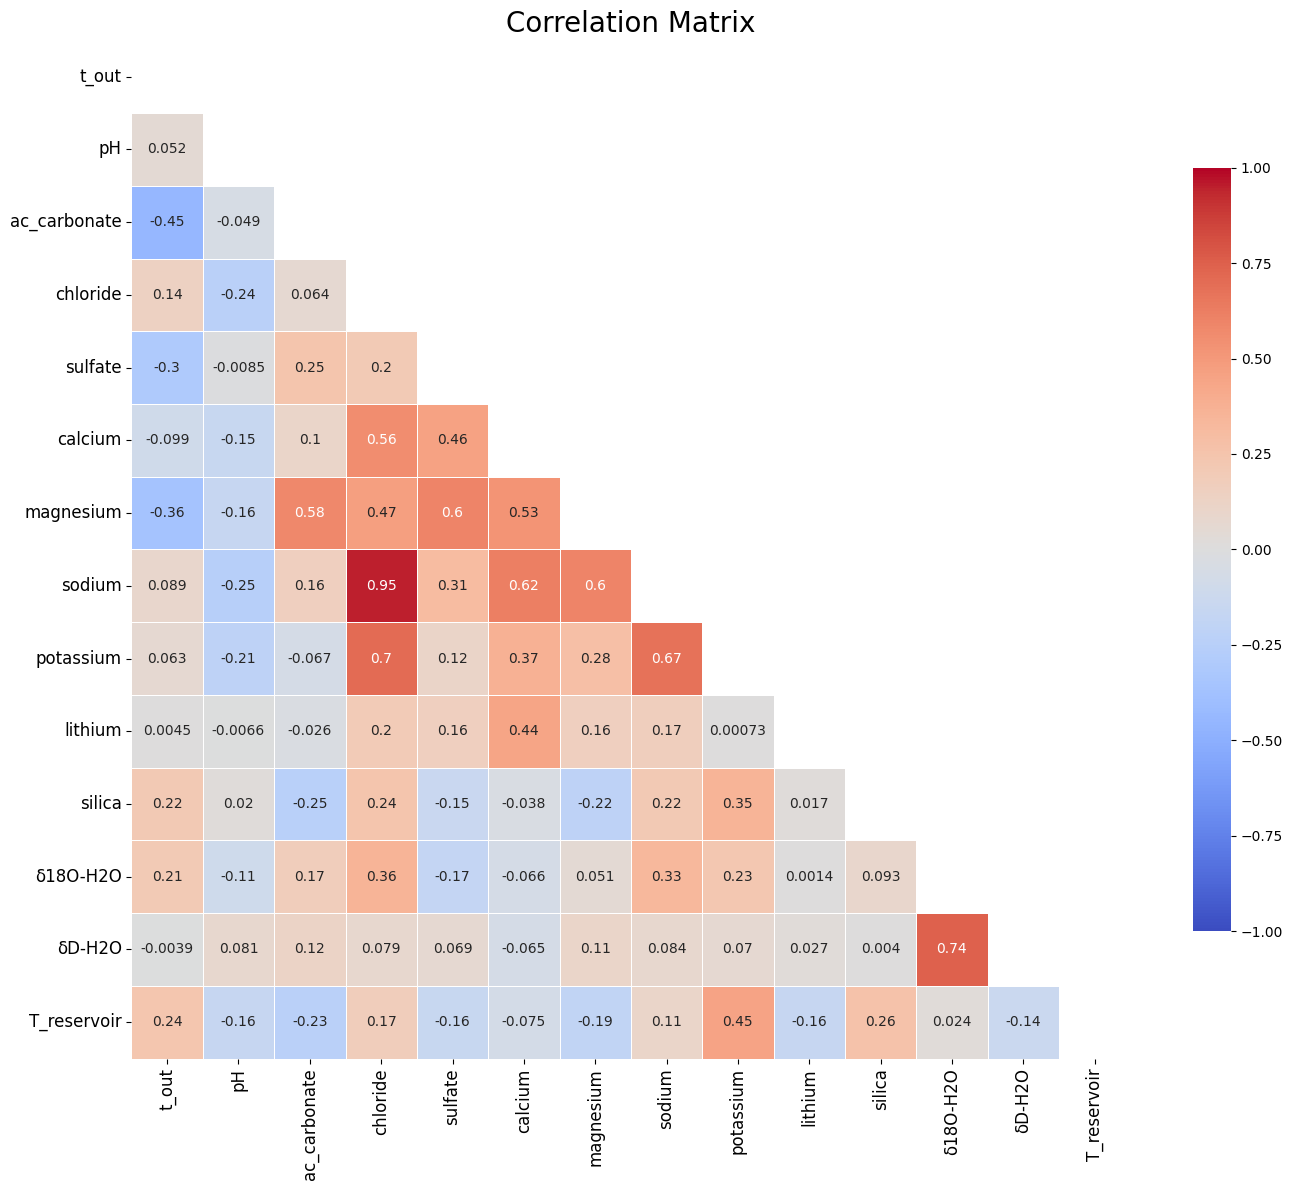

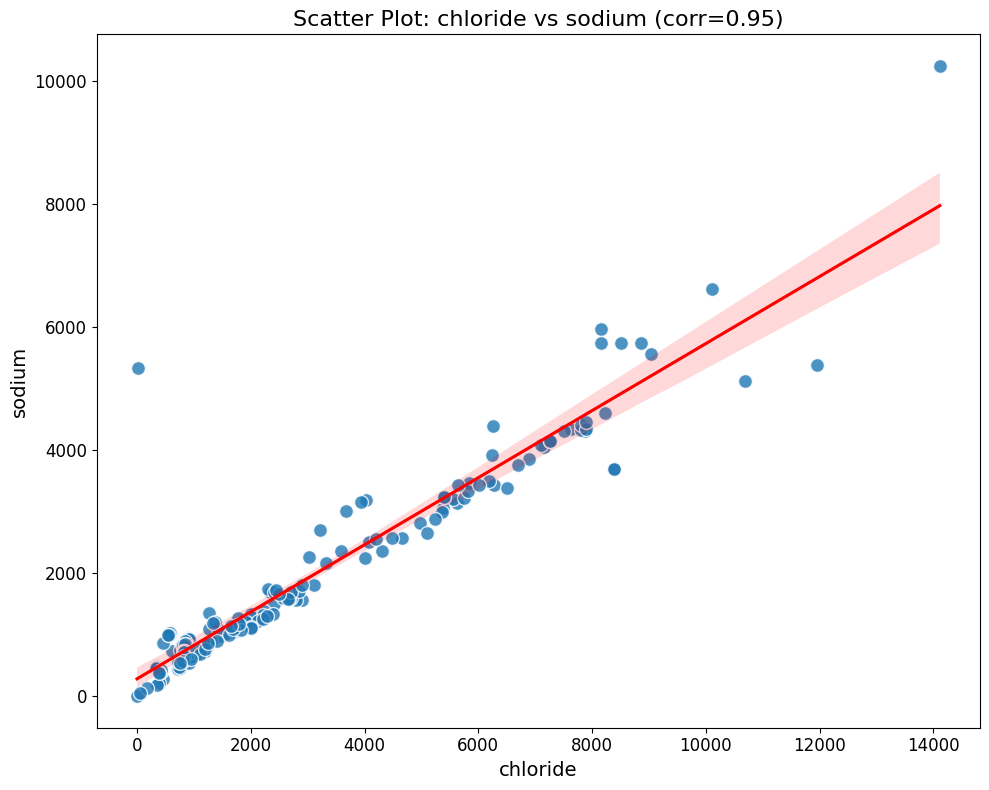

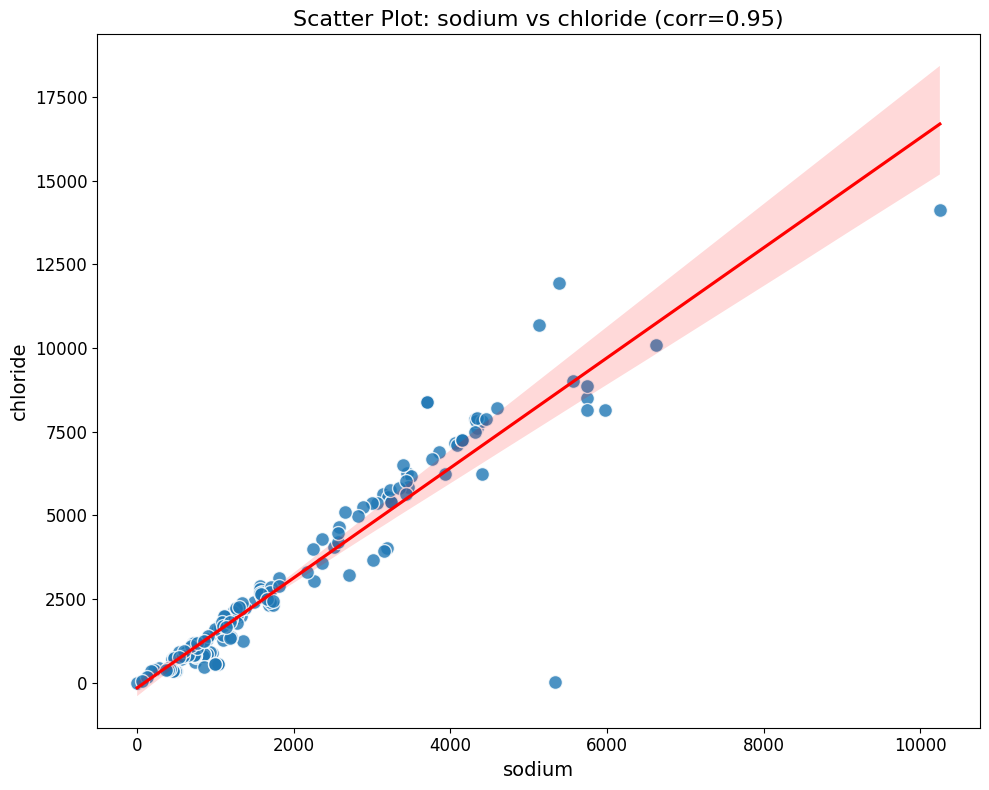

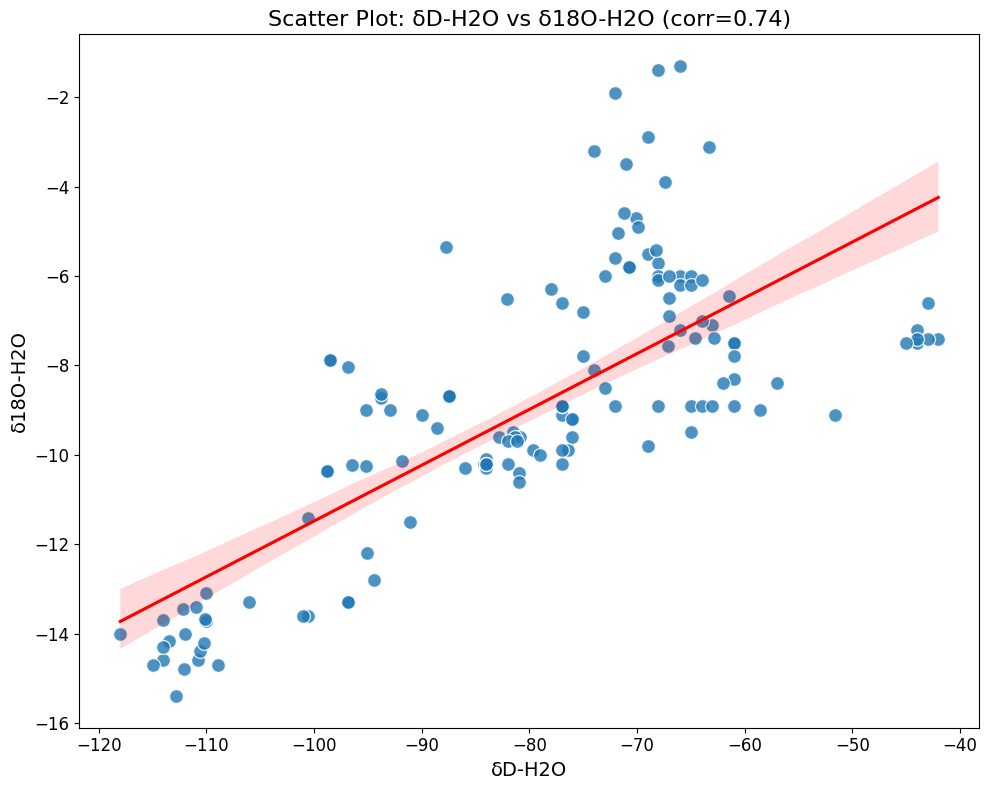

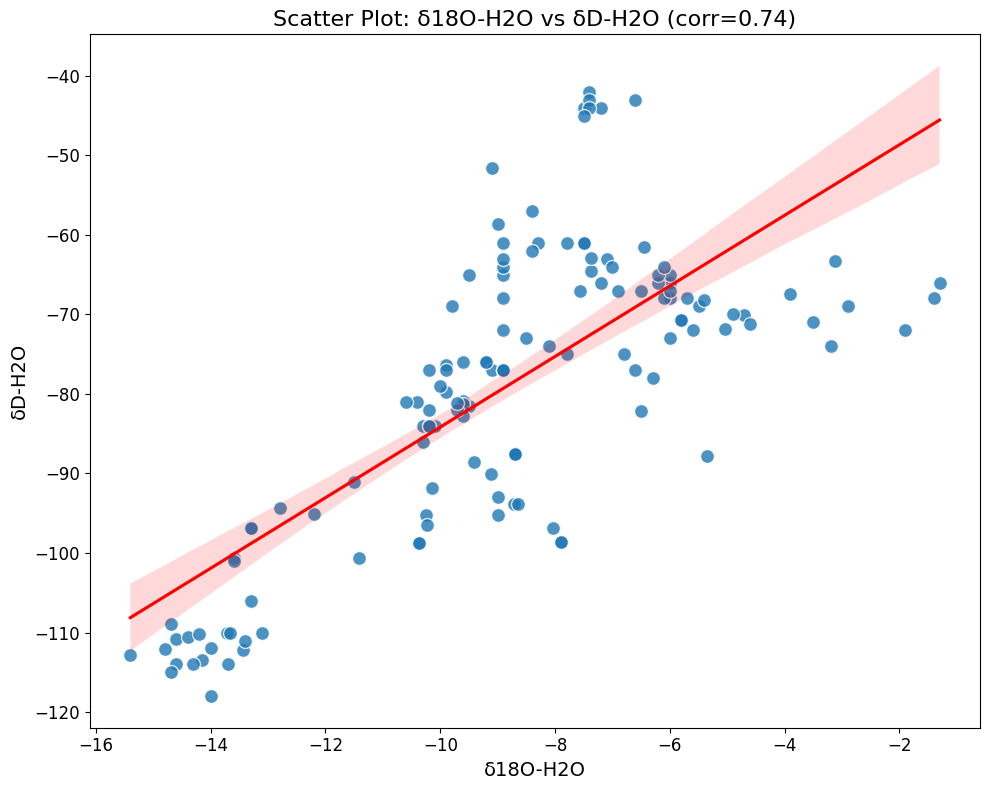

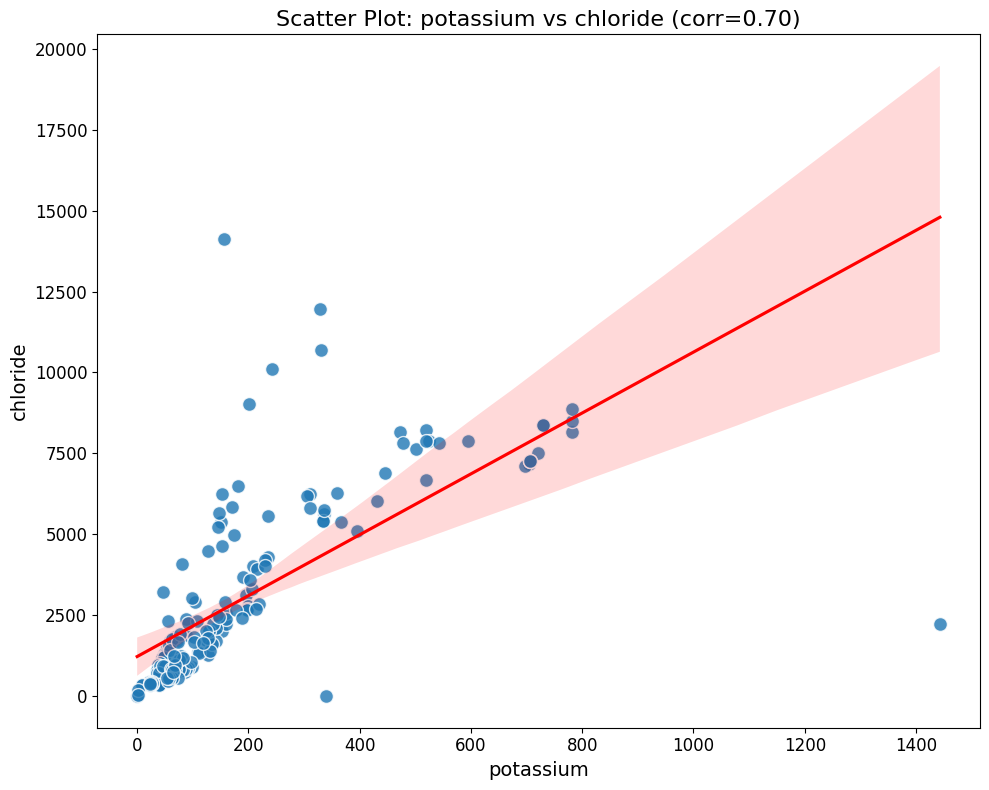

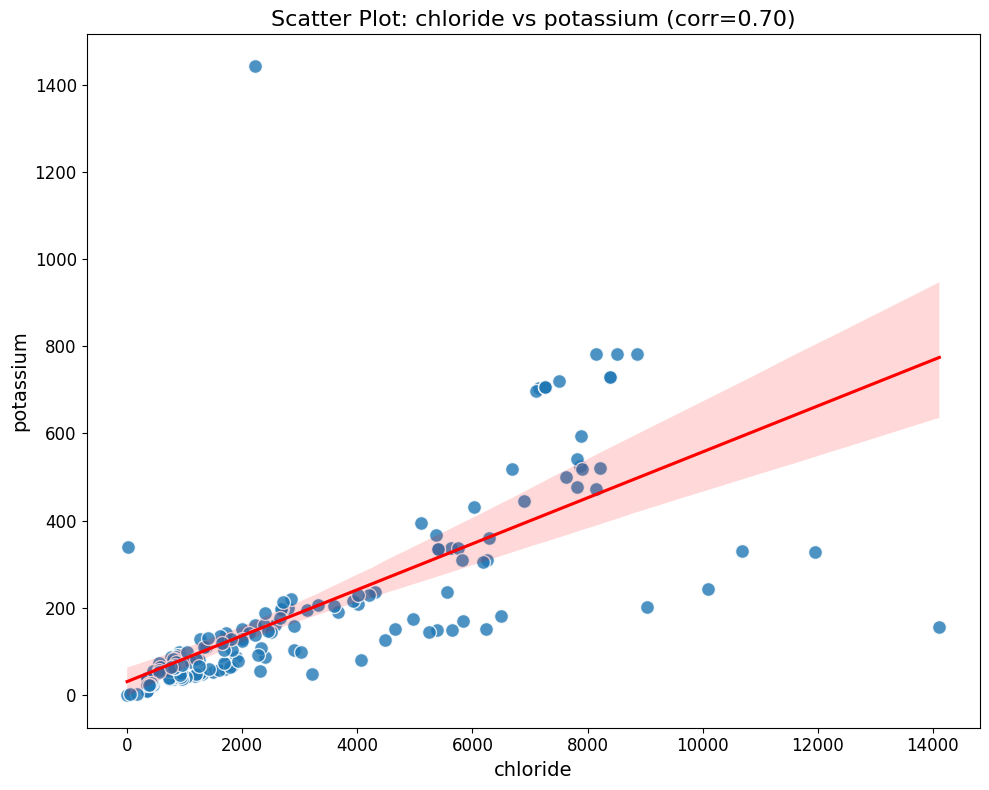

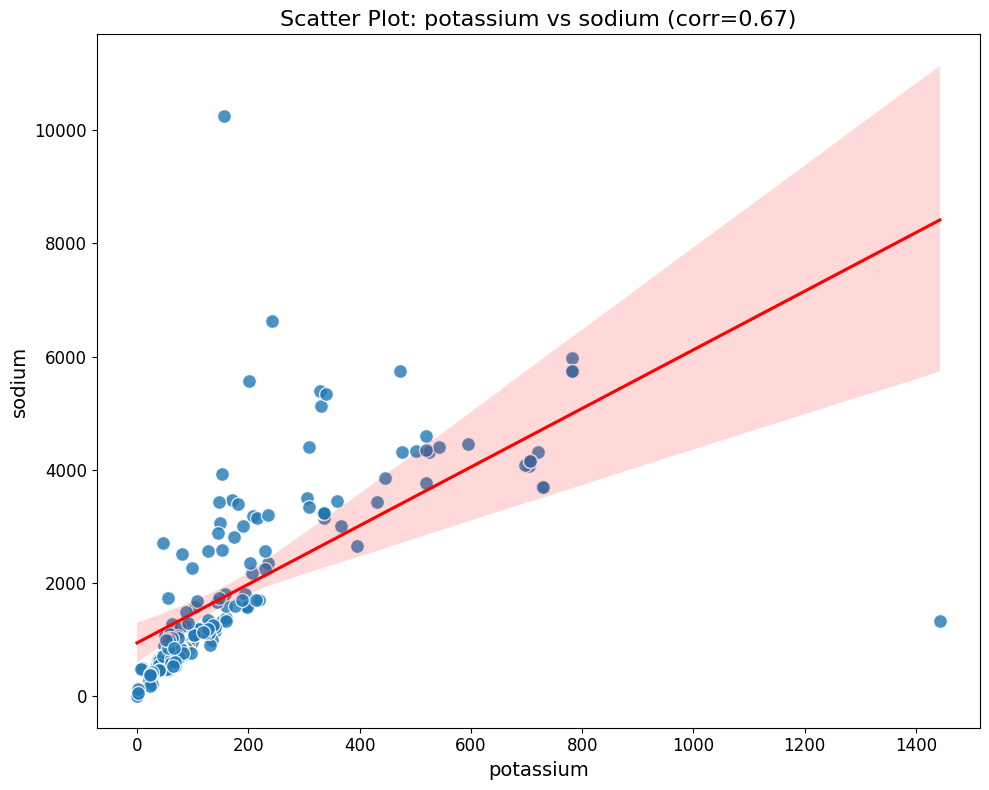

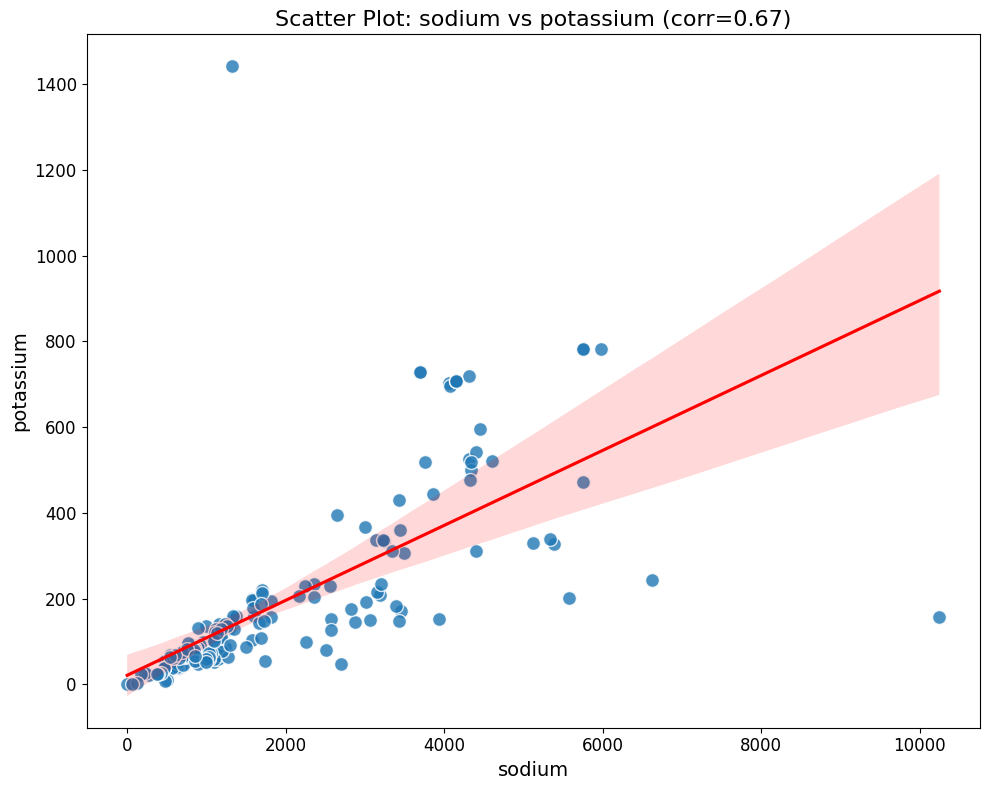

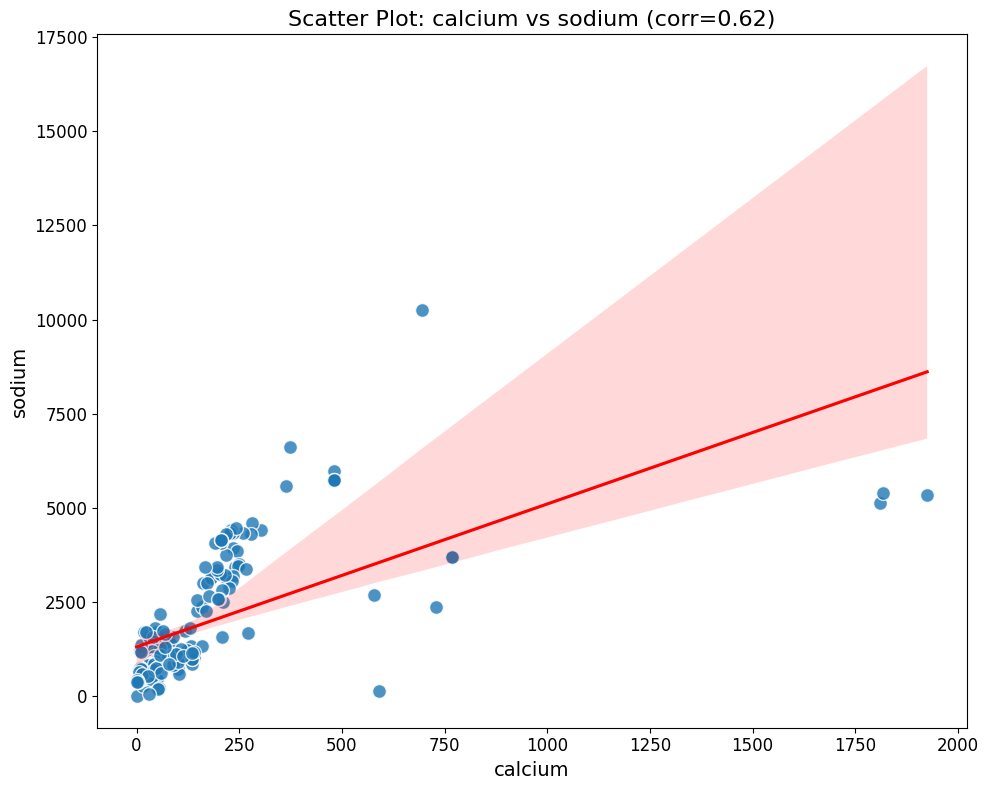

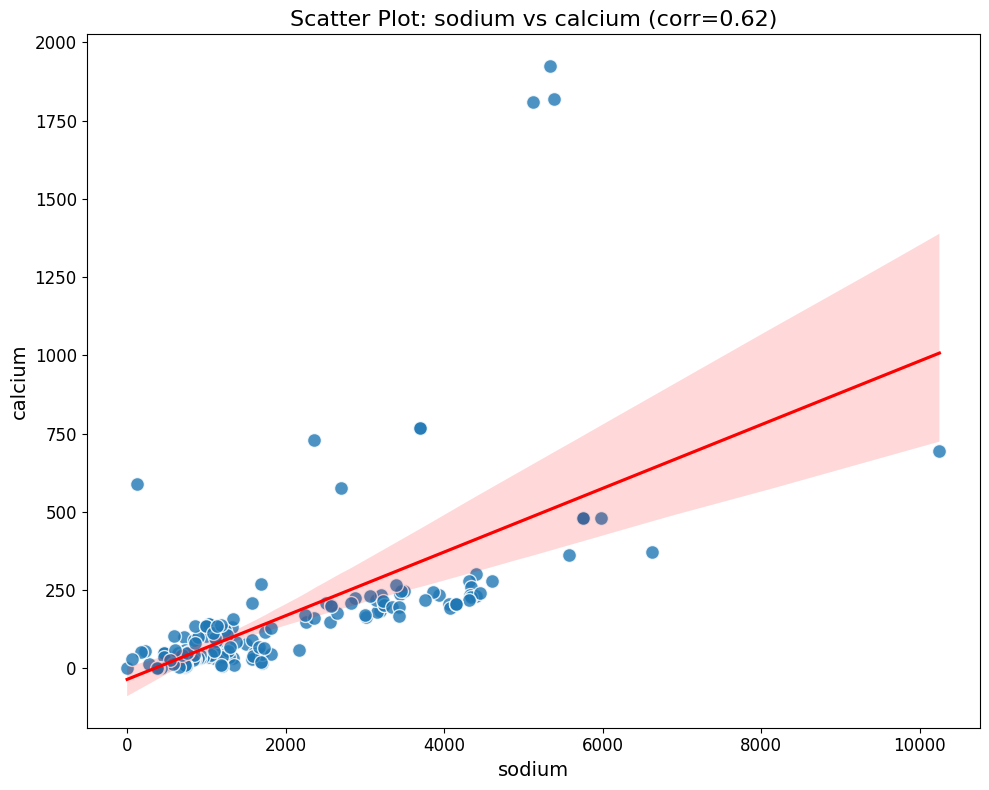

/tmp/ipykernel_25069/1691295175.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_final[df_final[cat_col].isin(top_categories)], palette="viridis")


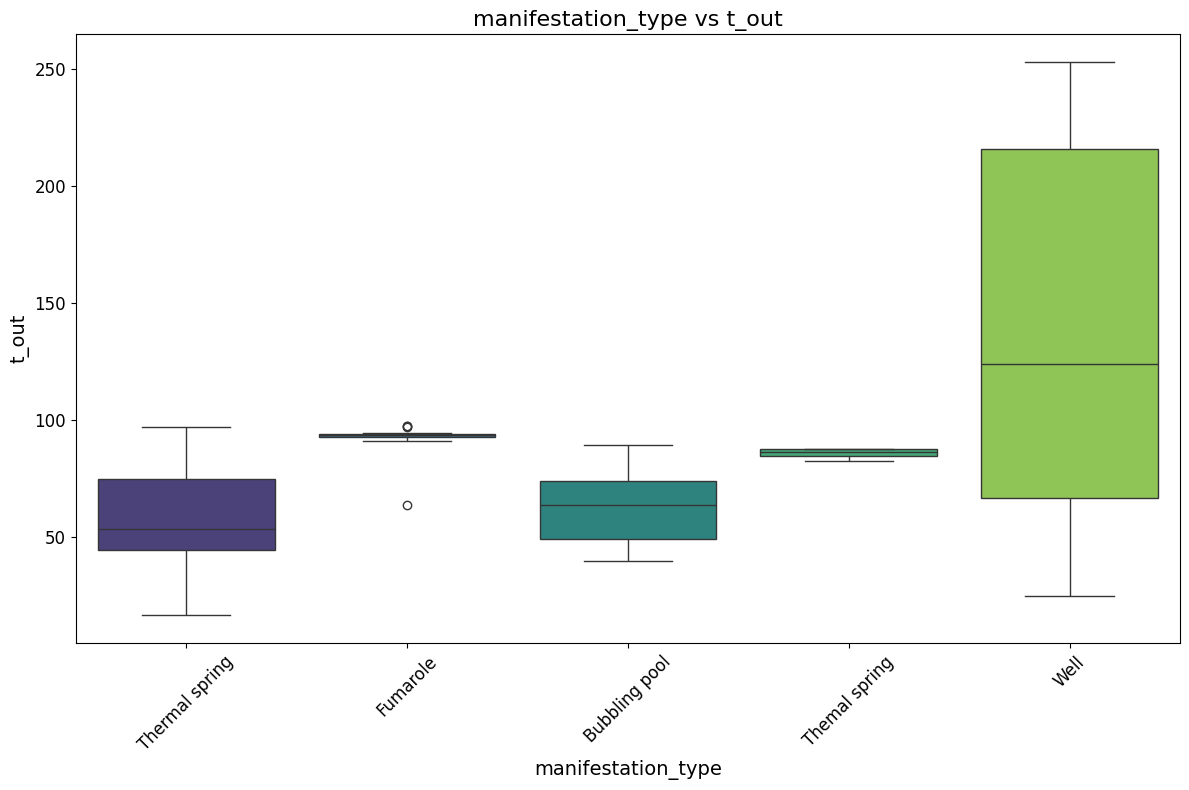

/tmp/ipykernel_25069/1691295175.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_final[df_final[cat_col].isin(top_categories)], palette="viridis")


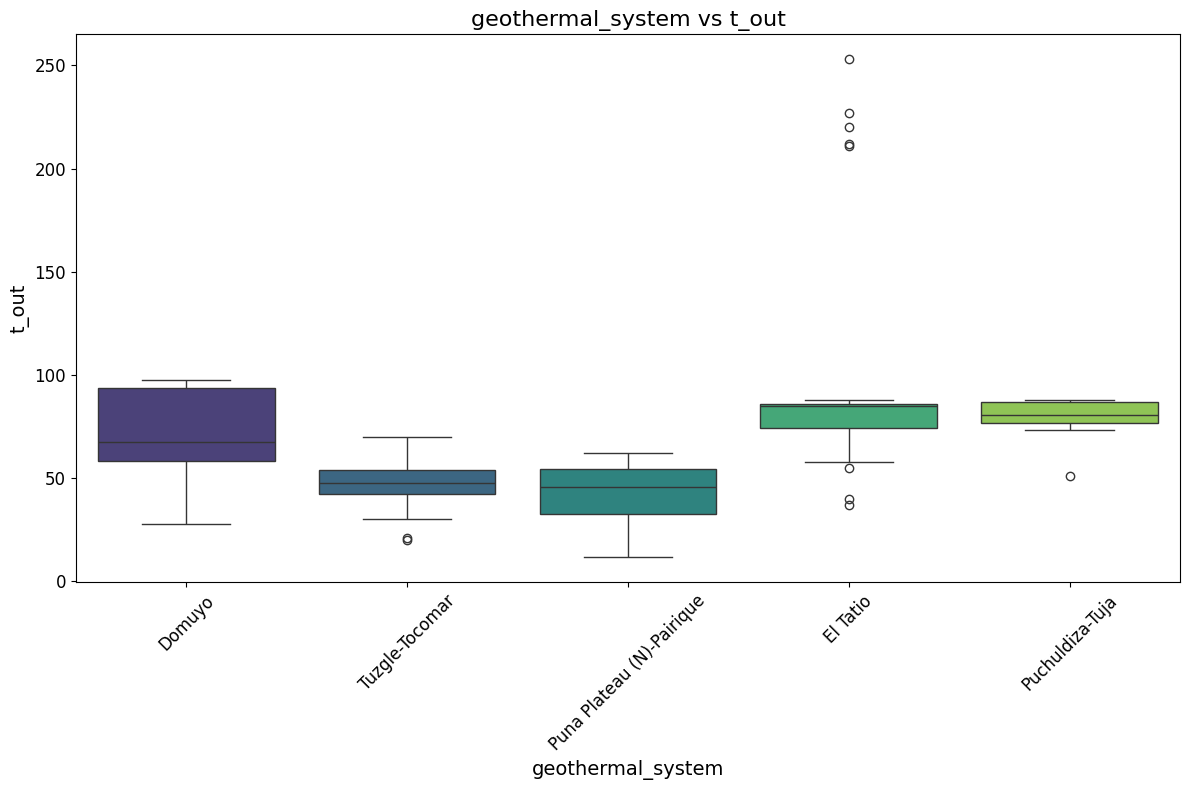

/tmp/ipykernel_25069/1691295175.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_final[df_final[cat_col].isin(top_categories)], palette="viridis")


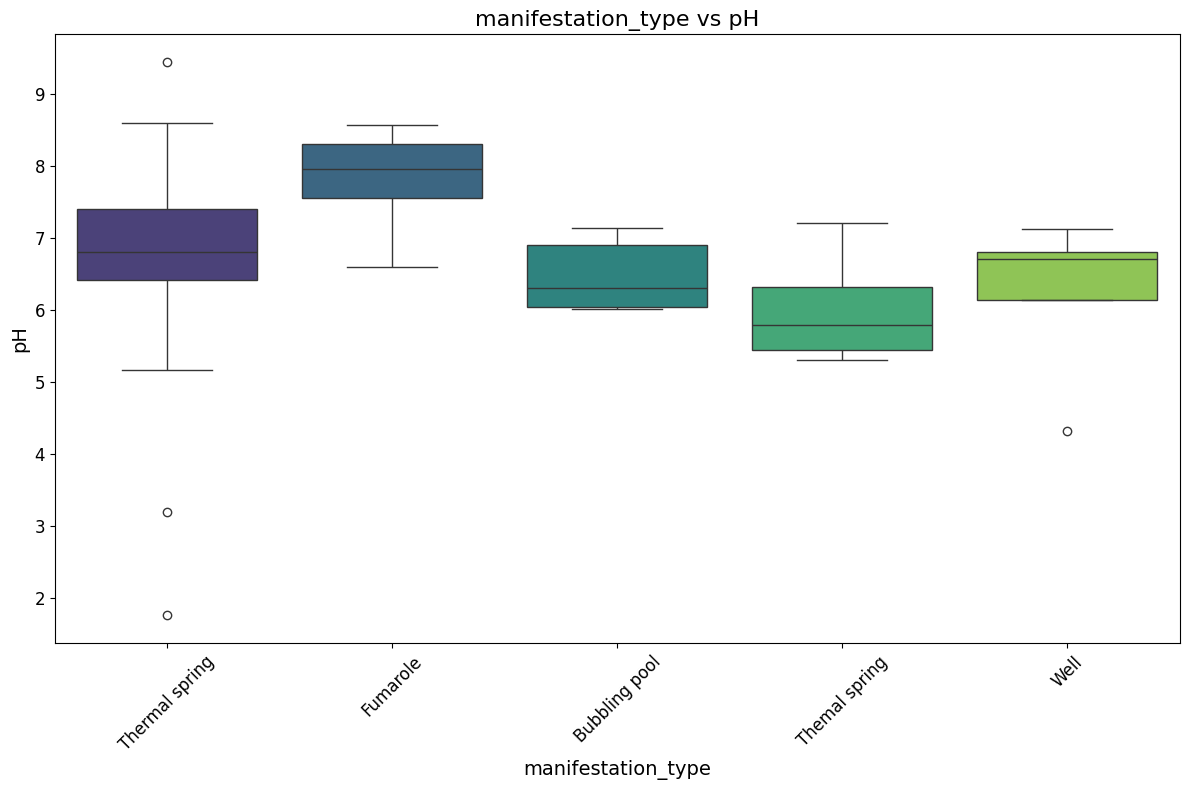

/tmp/ipykernel_25069/1691295175.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_final[df_final[cat_col].isin(top_categories)], palette="viridis")


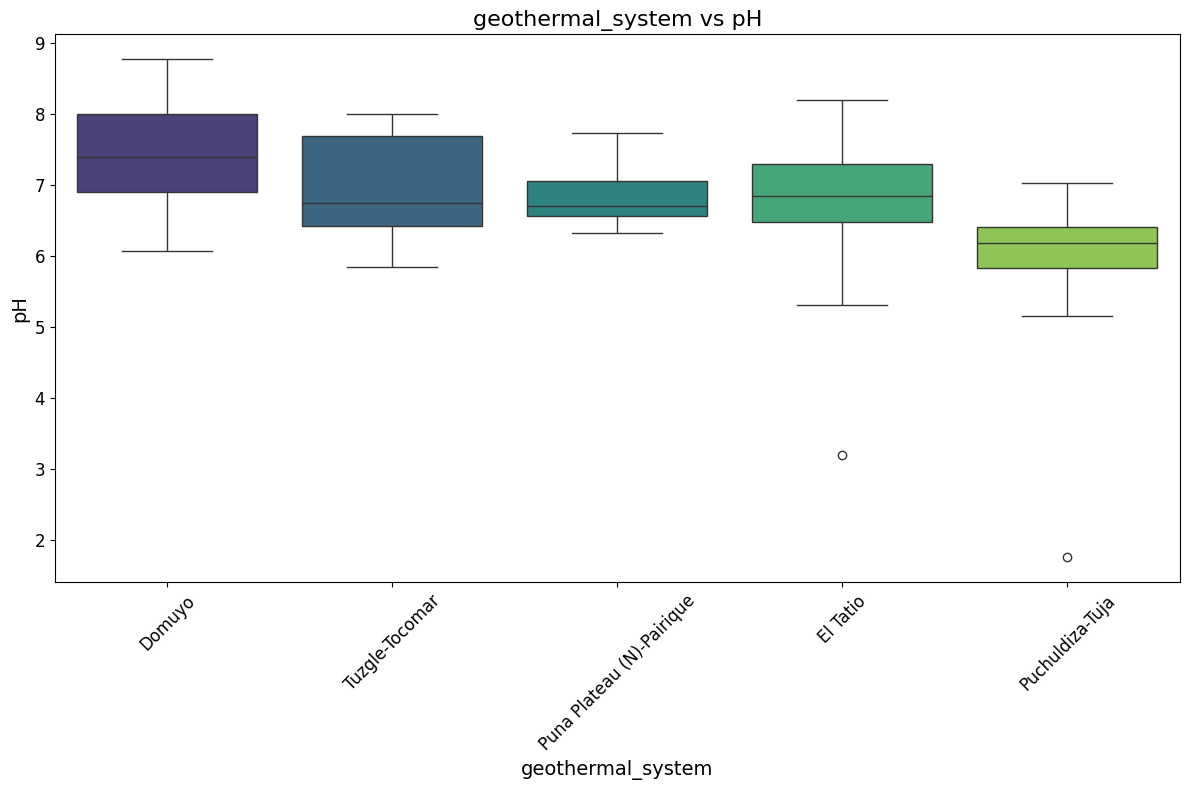

/tmp/ipykernel_25069/1691295175.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_final[df_final[cat_col].isin(top_categories)], palette="viridis")


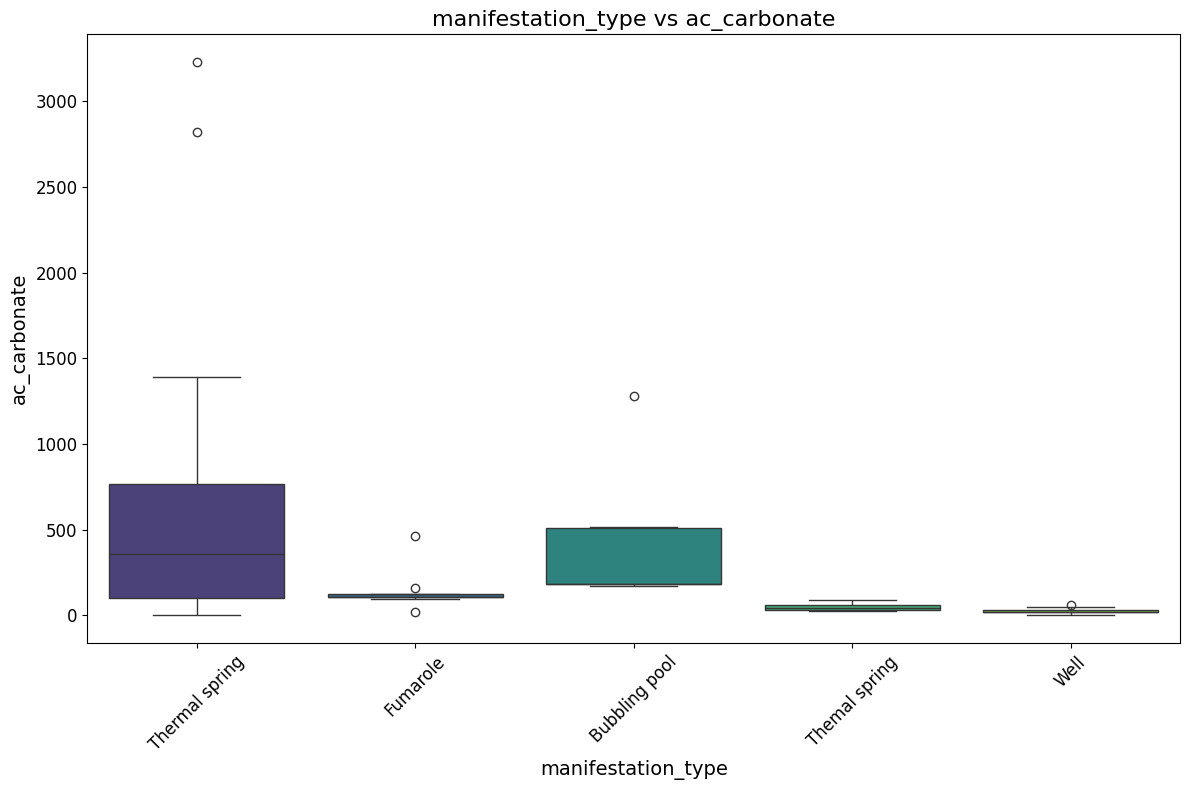

/tmp/ipykernel_25069/1691295175.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_final[df_final[cat_col].isin(top_categories)], palette="viridis")


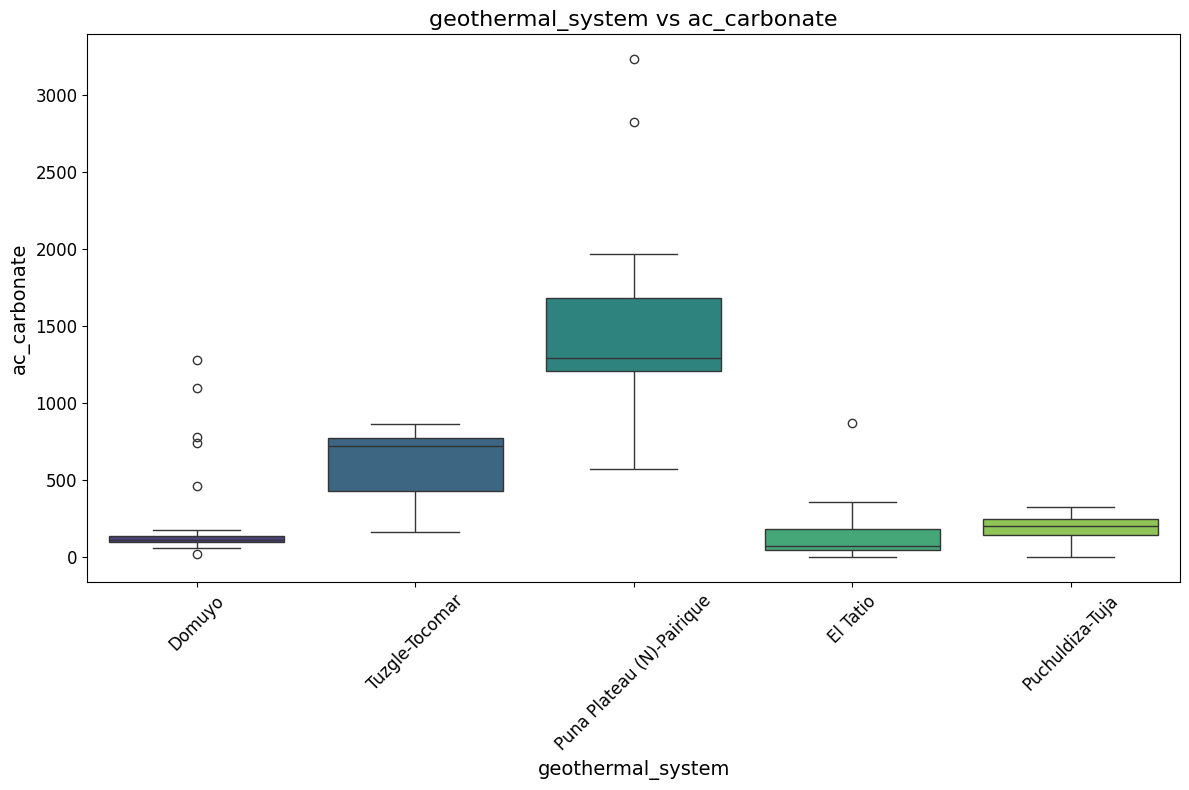

In [30]:
# Analyze relationships

# Correlation matrix for geochemical features

plt.figure(figsize=(14, 12))
correlation_matrix = df_final[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, mask=mask, cmap='coolwarm', 
            linewidths=0.5, vmin=-1, vmax=1, cbar_kws={"shrink": 0.75})
plt.title('Correlation Matrix', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
#plt.savefig('correlation_matrix.png')
plt.show()
plt.close()

corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # Remove self-correlations
#top_pairs = corr_pairs.nlargest(min(3, len(corr_pairs)))
top_pairs = corr_pairs[(corr_pairs >= 0.6) | (corr_pairs <= -0.6)]

for i, (pair, corr) in enumerate(top_pairs.items()):
    col1, col2 = pair
    plt.figure(figsize=(10, 8))
    sns.regplot(x=col1, y=col2, data=df_final, scatter_kws={'s': 100, 'edgecolor': 'w'}, line_kws={'color': 'red'})
    plt.title(f'Scatter Plot: {col1} vs {col2} (corr={corr:.2f})', fontsize=16)
    plt.xlabel(col1, fontsize=14)
    plt.ylabel(col2, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    #plt.savefig(f'scatter_{col1}_{col2}.png')
    plt.show()
    plt.close()

for num_col in numeric_cols[:min(3, len(numeric_cols))]:
    for cat_col in categorical_columns[:min(2, len(categorical_columns))]:
        plt.figure(figsize=(12, 8))
        top_categories = df_final[cat_col].value_counts().nlargest(5).index
        sns.boxplot(x=cat_col, y=num_col, data=df_final[df_final[cat_col].isin(top_categories)], palette="viridis")
        plt.title(f'{cat_col} vs {num_col}', fontsize=16)
        plt.xlabel(cat_col, fontsize=14)
        plt.ylabel(num_col, fontsize=14)
        plt.xticks(rotation=45, fontsize=12)
        plt.yticks(fontsize=12)
        plt.tight_layout()
        #plt.savefig(f'boxplot_{cat_col}_{num_col}.png')
        plt.show()
        plt.close()